![Banner](../../images/10_banner.png)


# 10. Capstone: End-to-End Workflow


**Part:** 10 — Capstone: End-to-End Workflow

**Dataset:** `diabetes_atlantic.shp` (666 Atlantic counties)

**Focus:** one health-geography study that uses the package from the CRS audit through to a decision log

**Library:** `core`, `weights`, `esda`, `viz`, `cluster`, `regression`, `gwmodel`, `bayes`, `interpolate`. The space–time step is deferred: `spatialstats.spacetime` is still a stub.


***

## Table of Contents

1. [Overview](#1.-Overview)

2. [Python Setup](#2.-Python-Setup)

3. [Data and CRS](#3.-Data-and-CRS)

4. [Weights, Sensitivity, and Islands](#4.-Weights,-Sensitivity,-and-Islands)

5. [Global and Local Autocorrelation](#5.-Global-and-Local-Autocorrelation)

6. [Hot Spots, LISA, and Regions](#6.-Hot-Spots,-LISA,-and-Regions)

7. [Explanation: OLS, LM Tests, SLM, and SEM](#7.-Explanation:-OLS,-LM-Tests,-SLM,-and-SEM)

8. [Heterogeneity: GWR and MGWR](#8.-Heterogeneity:-GWR-and-MGWR)

9. [Rates and Uncertainty](#9.-Rates-and-Uncertainty)

10. [Prediction at New Places](#10.-Prediction-at-New-Places)

11. [Decision Log and Summary Figure](#11.-Decision-Log-and-Summary-Figure)

12. [Summary and Conclusions](#12.-Summary-and-Conclusions)

13. [Resources](#13.-Resources)


***
## 1. Overview

The question is a single one, asked of one map: **where along the Atlantic seaboard is county adult-diabetes prevalence high, does that pattern cluster, what accounts for it, and which county rates are too noisy to read raw?**

Prevalence (`Dia_pct`) is the outcome for autocorrelation, clustering, regression, and geographically weighted regression. Counts (`Dia_count`) and population (`POP_Total`) are reserved for the rate section, where a percentage hides the fact that a small county and a large one are not equally precise.

| Step | What we do | Status |
|------|------------|--------|
| Data and CRS | Audit with `load_study_area`, keep EPSG:5070, map prevalence | ✅ |
| Weights | Queen contiguity, KNN sensitivity, and an island-linking rule | ✅ |
| Autocorrelation | Global Moran's I and the Moran scatterplot | ✅ |
| Clusters | Gi\* and LISA agreement, then SKATER regions | ✅ |
| Explanation | OLS, Lagrange-multiplier tests, spatial lag and spatial error | ✅ |
| Heterogeneity | Adaptive GWR and a fixed-kernel MGWR | ✅ |
| Rates | SMR, empirical Bayes, BYM, exceedance probabilities | ✅ |
| Prediction | IDW at new grid locations, scored by spatial-block cross-validation | ✅ |
| Reporting | Decision log and a one-page summary figure | ✅ |
| Space–time | A year dimension on this cross-section | 🔲 Deferred until `spacetime` exists |

Every number in the prose below is computed in this notebook. Permutation counts, the significance level, and the random seed are fixed in the setup cell and repeated in the decision log.


***
## 2. Python Setup


In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pyproj import Transformer
from scipy.spatial import cKDTree
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.core import SpatialData, to_crs
from spatialstats.weights import W, Queen, KNN, DistanceBand
from spatialstats.esda import Moran
from spatialstats.viz import moran_scatter
from spatialstats.cluster import (
    getis_ord_gi, local_moran_clusters, skater, jaccard, agreement_matrix,
)
from spatialstats.regression import OLS, SpatialLag, SpatialError, compare_models
from spatialstats.gwmodel.linear import GWR, MGWR
from spatialstats.bayes import expected_counts, smr, eb_gamma_poisson, BYM
from spatialstats.interpolate import IDW, cross_validate, make_grid

SEED = 7
PERM = 999
ALPHA = 0.05
COVARS = ["Obesity", "PhysInact", "SVI"]

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}
print(f"spatialstats : version {spatialstats.__version__}")
print(f"seed {SEED}  |  permutations {PERM}  |  alpha {ALPHA}")


spatialstats : version 0.2.0
seed 7  |  permutations 999  |  alpha 0.05


***
## 3. Data and CRS

The audit is the same recipe as Part 0: a declared CRS, a metric unit, features inside that CRS's area of use, valid geometries, and no missing values in the columns this study uses. `load_study_area` then reprojects. The file is already EPSG:5070 (NAD83 / Conus Albers, metres). Reprojecting to that same code is deliberate: it records the target, and it would have caught a geographic or a wrongly zoned layer.

Analysis coordinates are **polygon centroids of the projected geometry**. Stored `x` / `y` columns are not reused after reprojection (a `coords` role is not updated by `SpatialData.to_crs`), and `SpatialData.coords_array()` returns representative points, which on these counties sit kilometres from the centroid.


In [2]:
def crs_audit(gdf, name="layer"):
    """Return a DataFrame of data-quality checks for a GeoDataFrame."""
    rows = []
    add = lambda check, status, detail: rows.append({"check": check, "status": status, "detail": detail})
    crs = gdf.crs
    if crs is None:
        add("CRS declared", "FAIL", "no CRS: cannot reproject and units are unknown")
    else:
        add("CRS declared", "ok", crs.name)
        unit = crs.axis_info[0].unit_name
        add("metric projected CRS", "ok" if crs.is_projected and unit == "metre" else "warn",
            f"{'geographic' if crs.is_geographic else 'projected'}, unit = {unit}")
        if crs.area_of_use is not None:
            pts = gdf.geometry.representative_point()
            if crs.is_geographic:
                lon, lat = pts.x.to_numpy(), pts.y.to_numpy()
            else:
                lon, lat = Transformer.from_crs(crs, 4326, always_xy=True).transform(
                    pts.x.to_numpy(), pts.y.to_numpy())
            w, s, e, n = crs.area_of_use.bounds
            in_lon = (lon >= w) & (lon <= e) if w <= e else (lon >= w) | (lon <= e)
            frac = float(np.mean(in_lon & (lat >= s) & (lat <= n)))
            deg = lambda v, pos, neg: f"{abs(v):.0f}°{pos if v >= 0 else neg}"
            add("inside the CRS's area of use", "ok" if frac > 0.99 else "FAIL",
                f"{100 * frac:.0f}% of features; CRS is for {deg(w, 'E', 'W')} to {deg(e, 'E', 'W')}, "
                f"data at {abs(np.median(lon)):.1f}°{'E' if np.median(lon) >= 0 else 'W'}, "
                f"{abs(np.median(lat)):.1f}°{'N' if np.median(lat) >= 0 else 'S'}")
    bad = int((~gdf.geometry.is_valid).sum())
    empty = int(gdf.geometry.is_empty.sum())
    miss = int(gdf.geometry.isna().sum())
    add("valid, non-empty geometries", "ok" if bad + empty + miss == 0 else "warn",
        f"{bad} invalid, {empty} empty, {miss} missing")
    types = gdf.geom_type.value_counts().to_dict()
    add("geometry types", "ok" if len(types) == 1 else "note", str(types))
    dup = int(gdf.geometry.to_wkb().duplicated().sum())
    add("repeated geometries", "ok" if dup == 0 else "note",
        f"{dup} of {len(gdf)} features repeat an earlier geometry")
    add("unique index", "ok" if gdf.index.is_unique else "warn",
        f"{int(gdf.index.duplicated().sum())} duplicated index labels")
    return pd.DataFrame(rows).set_index("check")


def load_study_area(source, y=None, X=None, target_crs=None):
    """Load, audit and (optionally) reproject a layer. Returns (SpatialData, audit DataFrame)."""
    gdf = source if isinstance(source, gpd.GeoDataFrame) else gpd.read_file(source)
    report = crs_audit(gdf)
    roles = ([y] if isinstance(y, str) else list(y or [])) + list(X or [])
    n_missing = {c: int(gdf[c].isna().sum()) for c in roles}
    report.loc["no missing values in roles"] = (
        "ok" if not any(n_missing.values()) else "warn",
        str(n_missing) if roles else "no roles assigned",
    )
    if target_crs is not None:
        if gdf.crs is None:
            report.loc["reprojection"] = ("FAIL", "skipped: layer has no CRS")
        else:
            gdf = to_crs(gdf, target_crs)
            report.loc["reprojection"] = ("ok", f"-> EPSG:{gdf.crs.to_epsg()}")
    return SpatialData(gdf, y=y, X=X), report


study, audit = load_study_area(
    DATA / "diabetes_atlantic.shp", y="Dia_pct", X=COVARS + ["Dia_count", "POP_Total"], target_crs=5070,
)
counties = study.gdf.reset_index(drop=True)
centroids = counties.geometry.centroid
coords = np.column_stack([centroids.x.to_numpy(), centroids.y.to_numpy()])
y = counties["Dia_pct"].to_numpy(dtype=float)
X = counties[COVARS].to_numpy(dtype=float)
display(audit)
display(Markdown(
    f"**{len(counties)}** counties, geometry type **{study.geometry_type}**, "
    f"CRS **EPSG:{counties.crs.to_epsg()}**. "
    f"Prevalence ranges from **{y.min():.2f}** to **{y.max():.2f}** "
    f"(mean {y.mean():.2f})."
))


,status,detail
check,,
CRS declared,ok,NAD83 / Conus Albers
metric projected CRS,ok,"projected, unit = metre"
inside the CRS's area of use,ok,"100% of features; CRS is for 125°W to 67°W, da..."
"valid, non-empty geometries",ok,"0 invalid, 0 empty, 0 missing"
geometry types,note,"{'Polygon': 655, 'MultiPolygon': 11}"
repeated geometries,ok,0 of 666 features repeat an earlier geometry
unique index,ok,0 duplicated index labels
no missing values in roles,ok,"{'Dia_pct': 0, 'Obesity': 0, 'PhysInact': 0, '..."
reprojection,ok,-> EPSG:5070


**666** counties, geometry type **Mixed**, CRS **EPSG:5070**. Prevalence ranges from **5.86** to **16.96** (mean 9.14).

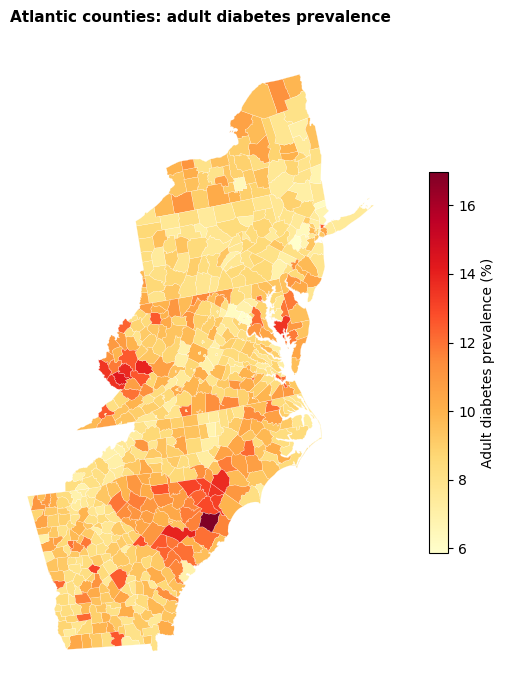

In [3]:
fig, ax = plt.subplots(figsize=(8, 7))
counties.plot(column="Dia_pct", cmap="YlOrRd", legend=True, ax=ax,
              edgecolor="white", linewidth=0.15,
              legend_kwds={"label": "Adult diabetes prevalence (%)", "shrink": 0.6})
ax.set_axis_off()
ax.set_title("Atlantic counties: adult diabetes prevalence")
plt.tight_layout()
# ALT: Choropleth of adult diabetes prevalence in percent for 666 Atlantic US counties in EPSG:5070, shaded from pale yellow to dark red, with higher prevalence concentrated in the inland South and lower prevalence along parts of the Northeast coast.


***
## 4. Weights, Sensitivity, and Islands

Queen contiguity (shared edge or vertex), row-standardised, is the working graph: a county is compared with the counties it touches. KNN is the sensitivity check, because a contiguity graph and a nearest-neighbour graph do not encode the same hypothesis.

A distance band is included only to show the island rule. A 50 km cutoff leaves some counties with no neighbour. Each of those islands is joined to its nearest county that is not itself an island, in both directions, and the weights are row-standardised again. Queen on this layer has no islands, so the rule does not change the analysis graph. It is here because the BYM model and SKATER both need a graph whose components you have decided about, and the next file may not be this well connected.


In [4]:
def attach_islands(w, xy):
    """Link each island to its nearest non-island county, both ways, then row-standardise."""
    ids = list(w.id_order)
    pos = {i: k for k, i in enumerate(ids)}
    islands = set(w.islands())
    neighbors = {i: list(w.neighbors[i]) for i in ids}
    if not islands:
        return W(neighbors, ids=ids, transform="row")
    tree = cKDTree(xy)
    for isl in islands:
        _, idxs = tree.query(xy[pos[isl]], k=len(ids))
        for j in np.atleast_1d(idxs):
            other = ids[int(j)]
            if other == isl or other in islands:
                continue
            if other not in neighbors[isl]:
                neighbors[isl].append(other)
            if isl not in neighbors[other]:
                neighbors[other].append(isl)
            break
    return W(neighbors, ids=ids, transform="row")


w = Queen(counties, transform="row")
print(w.summary())

band = DistanceBand(counties, threshold=50_000, binary=True, transform="binary")
linked = attach_islands(band, coords)
island_tbl = pd.DataFrame({
    "graph": ["Queen", "50 km band", "50 km band, islands linked"],
    "islands": [len(w.islands()), len(band.islands()), len(linked.islands())],
    "components": [w.n_components(), band.n_components(), linked.n_components()],
    "mean neighbours": [
        w.cardinalities().mean(), band.cardinalities().mean(), linked.cardinalities().mean(),
    ],
}).round(2)
display(island_tbl)

knn_rows = []
for k in (4, 6, 8, 12):
    wk = KNN(counties, k=k, transform="row")
    mk = Moran(y, wk, permutations=PERM, seed=SEED)
    knn_rows.append({"weights": f"KNN k={k}", "I": mk.I, "p_sim": mk.p_value, "islands": len(wk.islands())})
mq = Moran(y, w, permutations=PERM, seed=SEED)
knn_rows.insert(0, {"weights": "Queen", "I": mq.I, "p_sim": mq.p_value, "islands": len(w.islands())})
weight_sens = pd.DataFrame(knn_rows)
display(weight_sens.round(4))
display(Markdown(
    f"Queen has **{len(w.islands())}** islands and **{w.n_components()}** component. "
    f"The 50 km band has **{len(band.islands())}** islands in **{band.n_components()}** components; "
    f"after linking, **{len(linked.islands())}** islands remain in **{linked.n_components()}** component(s). "
    f"Moran's I of prevalence is **{weight_sens['I'].min():.3f}** to **{weight_sens['I'].max():.3f}** "
    f"across these graphs, all with permutation p = **{weight_sens['p_sim'].max():.3f}** or smaller. "
    f"The rest of the study uses **Queen**."
))


Spatial Weights (W)
  Observations        666
  Transform           row
  Min neighbors       1
  Mean neighbors      5.423
  Max neighbors       11
  Islands             0
  Components          1
  Nonzero weights     3612


,graph,islands,components,mean neighbours
0,Queen,0,1,5.42
1,50 km band,3,6,5.96
2,"50 km band, islands linked",0,3,5.97


,weights,I,p_sim,islands
0,Queen,0.3707,0.001,0
1,KNN k=4,0.3707,0.001,0
2,KNN k=6,0.3762,0.001,0
3,KNN k=8,0.3594,0.001,0
4,KNN k=12,0.3219,0.001,0


Queen has **0** islands and **1** component. The 50 km band has **3** islands in **6** components; after linking, **0** islands remain in **3** component(s). Moran's I of prevalence is **0.322** to **0.376** across these graphs, all with permutation p = **0.001** or smaller. The rest of the study uses **Queen**.

***
## 5. Global and Local Autocorrelation

$$
I = \frac{n}{\sum_i \sum_j w_{ij}}
\frac{\sum_i \sum_j w_{ij}(y_i-\bar y)(y_j-\bar y)}{\sum_i (y_i-\bar y)^2}
$$

with row-standardised Queen weights the first factor equals 1. The p-value is from 999 permutations of the prevalence values (`seed=7`). The scatterplot is mean-centred, not z-scored: the axis label in `moran_scatter` says "standardized", which overstates what the function does.


Moran's I = **0.371** (expected under the null **-0.0015**), z = **15.15**, permutation p = **0.001** from 999 permutations. Prevalence is positively autocorrelated: high counties sit next to high counties.

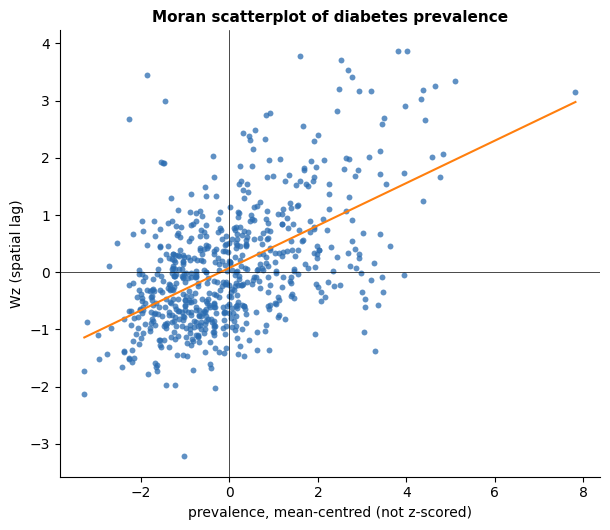

In [5]:
moran = Moran(y, w, permutations=PERM, seed=SEED)
display(Markdown(
    f"Moran's I = **{moran.I:.3f}** (expected under the null **{moran['expected_I']:.4f}**), "
    f"z = **{moran.z_score:.2f}**, permutation p = **{moran.p_value:.3f}** "
    f"from {moran['permutations']} permutations. "
    f"Prevalence is positively autocorrelated: high counties sit next to high counties."
))

fig, ax = plt.subplots(figsize=(6.2, 5.4))
moran_scatter(moran, ax=ax, s=18, c=COLORS["blue"], alpha=0.75, linewidths=0)
ax.set_xlabel("prevalence, mean-centred (not z-scored)")
ax.set_title("Moran scatterplot of diabetes prevalence")
plt.tight_layout()
# ALT: Moran scatterplot of mean-centred adult diabetes prevalence against its Queen-weights spatial lag for 666 Atlantic counties, with a positive slope and most points in the high-high and low-low quadrants.


***
## 6. Hot Spots, LISA, and Regions

Gi\* (analytic z-score, Benjamini–Hochberg FDR) asks where a county and its neighbours are jointly high or jointly low. Local Moran asks a different question: high-high and low-low clusters, and high-low / low-high outliers. The two maps should agree on the clusters and disagree on the outliers.

FDR on the LISA permutation p-values is reported beside the uncorrected map. With 999 permutations the smallest two-sided p-value is $2/1000 = 0.002$. Benjamini–Hochberg can declare a county at that floor only if enough other counties share it: the most counties that can pass is on the order of $n \times (2/1000) / \alpha$. The corrected map is that resolution ceiling. Gi\* can mark more counties after FDR because its p-values are analytic. Agreement is therefore shown for both the uncorrected LISA labels and the FDR labels.

SKATER then cuts the Queen minimum spanning tree into six contiguous regions on prevalence and the three covariates, so the cluster map is not the only regional summary.


In [6]:
gi = getis_ord_gi(y, w, star=True, inference="analytic", permutations=0,
                  correction="fdr", alpha=ALPHA)
lisa_fdr = local_moran_clusters(y, w, permutations=PERM, correction="fdr", alpha=ALPHA, seed=SEED)
lisa = local_moran_clusters(y, w, permutations=PERM, correction="none", alpha=ALPHA, seed=SEED)

gi_counts = pd.Series(gi.labels).value_counts()
hot = np.array([str(l).startswith("Hot") for l in gi.labels])
cold = np.array([str(l).startswith("Cold") for l in gi.labels])
hh = lisa.labels == "HH"
ll = lisa.labels == "LL"
agree = agreement_matrix({
    "Gi* hot": hot,
    "Gi* cold": cold,
    "LISA HH (no correction)": hh,
    "LISA LL (no correction)": ll,
    "LISA HH (FDR)": lisa_fdr.labels == "HH",
})
display(gi_counts.rename("count").to_frame())
display(Markdown(
    f"Uncorrected LISA ({PERM} permutations): "
    f"**{int((lisa.labels == 'HH').sum())}** HH, **{int((lisa.labels == 'LL').sum())}** LL, "
    f"**{int((lisa.labels == 'HL').sum())}** HL, **{int((lisa.labels == 'LH').sum())}** LH. "
    f"FDR LISA flags **{int((lisa_fdr.labels != 'Not significant').sum())}** counties. "
    f"The permutation floor is **{2 / (PERM + 1):.4f}**; "
    f"alpha / n = **{ALPHA / len(y):.5f}**."
))
display(agree.round(3))
n_fdr = int((lisa_fdr.labels != "Not significant").sum())
fdr_ceiling = int(np.floor(len(y) * (2 / (PERM + 1)) / ALPHA))
display(Markdown(
    f"Jaccard overlap of Gi\* hot spots with uncorrected LISA HH is "
    f"**{jaccard(hot, hh):.2f}**. Overlap of Gi\* cold spots with LISA LL is "
    f"**{jaccard(cold, ll):.2f}**. "
    f"Gi\* hot spots and LISA LL overlap by **{jaccard(hot, ll):.2f}**. "
    f"FDR keeps **{n_fdr}** LISA counties "
    f"(HH overlap with Gi\* hot spots **{jaccard(hot, lisa_fdr.labels == 'HH'):.2f}**). "
    f"At this permutation floor the Benjamini–Hochberg rule can declare at most about "
    f"**{fdr_ceiling}** counties, which is why the corrected map is smaller than the uncorrected one "
    f"and why it is not empty."
))


,count
Not significant,596
Hot spot 99%,28
Hot spot 95%,17
Hot spot 90%,13
Cold spot 90%,10
Cold spot 95%,2


Uncorrected LISA (999 permutations): **61** HH, **48** LL, **9** HL, **3** LH. FDR LISA flags **27** counties. The permutation floor is **0.0020**; alpha / n = **0.00008**.

,Gi* hot,Gi* cold,LISA HH (no correction),LISA LL (no correction),LISA HH (FDR)
Gi* hot,1.000,0.00,0.831,0.00,0.397
Gi* cold,0.000,1.00,0.000,0.25,0.000
LISA HH (no correction),0.831,0.00,1.000,0.00,0.377
LISA LL (no correction),0.000,0.25,0.000,1.00,0.000
LISA HH (FDR),0.397,0.00,0.377,0.00,1.000


Jaccard overlap of Gi\* hot spots with uncorrected LISA HH is **0.83**. Overlap of Gi\* cold spots with LISA LL is **0.25**. Gi\* hot spots and LISA LL overlap by **0.00**. FDR keeps **27** LISA counties (HH overlap with Gi\* hot spots **0.40**). At this permutation floor the Benjamini–Hochberg rule can declare at most about **26** counties, which is why the corrected map is smaller than the uncorrected one and why it is not empty.

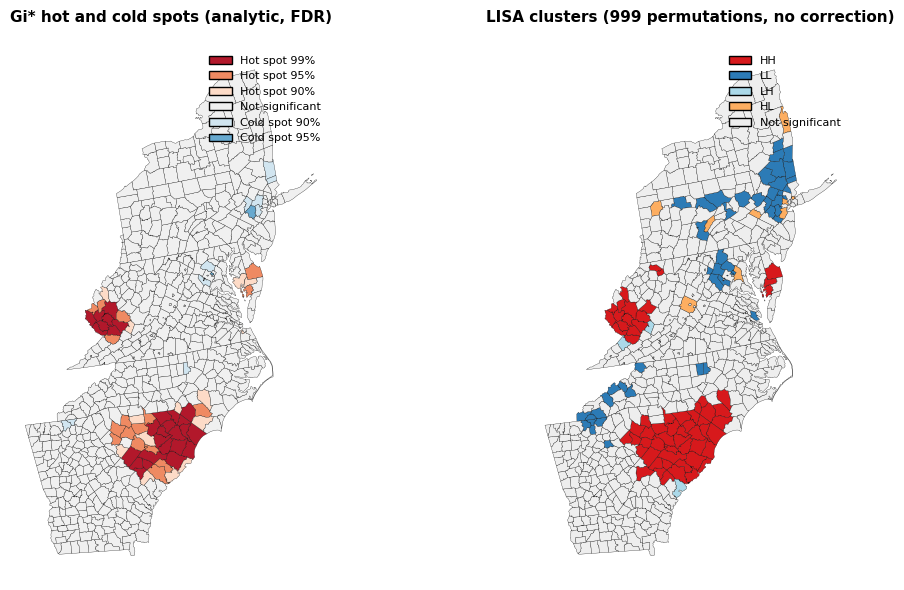

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
gi.plot(counties, ax=axes[0])
axes[0].set_title("Gi* hot and cold spots (analytic, FDR)")
lisa.plot(counties, ax=axes[1])
axes[1].set_title("LISA clusters (999 permutations, no correction)")
plt.tight_layout()
# ALT: Two county maps of the Atlantic seaboard. The left map shows Getis-Ord Gi-star hot spots in red and cold spots in blue after FDR, with most counties unshaded. The right map shows uncorrected local Moran clusters, with high-high and low-low counties in the same broad regions and a few high-low and low-high outliers.


SKATER produced **6** regions, attribute R² = **0.32**, every region contiguous under Queen weights: **True**. Region sizes: 13, 82, 11, 28, 281, 251.

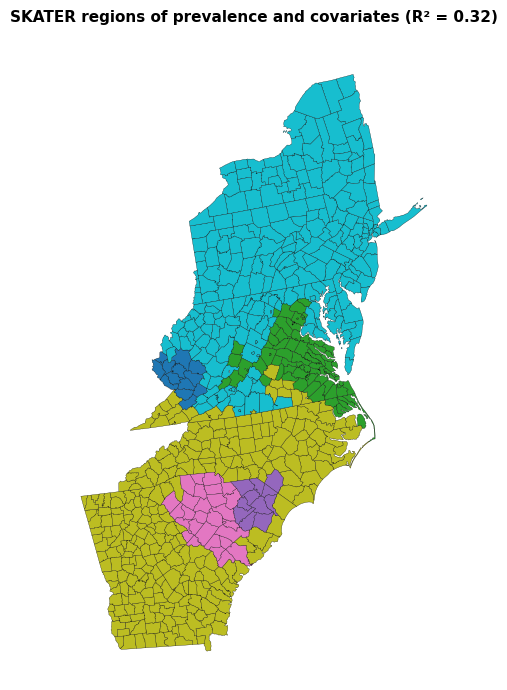

In [8]:
regions = skater(counties[["Dia_pct", *COVARS]], w, n_clusters=6, min_size=10)
counties = counties.copy()
counties["region"] = regions.labels
display(Markdown(
    f"SKATER produced **{regions._stats['n_regions']}** regions, "
    f"attribute R² = **{regions.r2:.2f}**, "
    f"every region contiguous under Queen weights: **{regions.is_contiguous(w)}**. "
    f"Region sizes: {', '.join(str(int(s)) for s in regions.sizes)}."
))

fig, ax = plt.subplots(figsize=(8, 7))
regions.plot(counties, ax=ax, cmap="tab10")
ax.set_title(f"SKATER regions of prevalence and covariates (R² = {regions.r2:.2f})")
plt.tight_layout()
# ALT: Categorical map of six contiguous SKATER regions covering the Atlantic counties, each region a single connected block of counties coloured differently, grouping places with similar diabetes prevalence, obesity, inactivity, and social vulnerability.


***
## 7. Explanation: OLS, LM Tests, SLM, and SEM

The mean model is prevalence on obesity, physical inactivity, and the social-vulnerability index. OLS is the baseline. The Lagrange-multiplier tests, computed from the OLS residuals and the Queen weights, choose between a spatial lag (neighbours' prevalence spills over) and a spatial error (the residuals are what cluster). Both spatial models are then fitted by maximum likelihood and compared on AIC, which is valid here because they use the same observations and the same weights.

Coefficients in the lag model are not marginal effects. A change in obesity in one county moves neighbours' prevalence through $\rho W y$. The model comparison below is about dependence, not about quoting a single "effect of obesity".


In [9]:
ols = OLS(y, X, w=w, y_name="Dia_pct", names=COVARS)
lm = ols.lm_tests(alpha=ALPHA)
display(ols.coef_frame().round(4))
display(lm.to_frame().round(4))
display(Markdown(
    f"OLS R² = **{ols.r2:.3f}**, AIC = **{ols.aic:.1f}**. "
    f"LM recommendation at alpha {ALPHA}: **{lm.recommendation()}**."
))

slm = SpatialLag(y, X, w, y_name="Dia_pct", names=COVARS)
sem = SpatialError(y, X, w, y_name="Dia_pct", names=COVARS)
cmp = compare_models({"OLS": ols, "SLM": slm, "SEM": sem})
display(cmp.round(4))
best_name = cmp["aic"].idxmin()
best_model = {"OLS": ols, "SLM": slm, "SEM": sem}[best_name]
display(Markdown(
    f"Lowest AIC is **{best_name}** ({cmp.loc[best_name, 'aic']:.1f}), "
    f"against OLS {cmp.loc['OLS', 'aic']:.1f}. "
    f"SLM ρ = **{slm.rho:.3f}** (p = {slm.spatial_p:.3g}); "
    f"SEM λ = **{sem.lam:.3f}** (p = {sem.spatial_p:.3g}). "
    f"Residual Moran's I falls from **{cmp.loc['OLS', 'resid_moran_I']:.3f}** under OLS "
    f"to **{cmp.loc[best_name, 'resid_moran_I']:.3f}** under {best_name}."
))


,variable,coef,std_err,t,p_value
0,const,0.9598,0.2003,4.7929,0.0
1,Obesity,0.1408,0.0114,12.3952,0.0
2,PhysInact,0.1555,0.0150,10.3748,0.0
3,SVI,1.6385,0.1290,12.7000,0.0


,test,statistic,df,p_value
0,LM-Lag,56.6924,1,0.0000
1,Robust LM-Lag,7.5769,1,0.0059
2,LM-Error,87.2835,1,0.0000
3,Robust LM-Error,38.1680,1,0.0000
4,LM-SARMA,94.8603,2,0.0000


OLS R² = **0.727**, AIC = **1627.3**. LM recommendation at alpha 0.05: **Spatial error model (both robust tests significant; larger statistic chosen — consider SARMA/Durbin)**.

,n_params,loglik,aic,bic,pseudo_r2,rho,lambda,resid_moran_I,resid_moran_p
model,,,,,,,,,
OLS,4,-809.6499,1627.2998,1645.3049,0.7269,NaN,NaN,0.2306,0.0000
SLM,5,-784.6831,1579.3662,1601.8726,0.7490,0.2178,NaN,0.0874,0.0003
SEM,5,-774.7195,1559.4389,1581.9454,0.7240,NaN,0.42,-0.0312,0.2274


Lowest AIC is **SEM** (1559.4), against OLS 1627.3. SLM ρ = **0.218** (p = 1.94e-12); SEM λ = **0.420** (p = 3.43e-18). Residual Moran's I falls from **0.231** under OLS to **-0.031** under SEM.

***
## 8. Heterogeneity: GWR and MGWR

A single SEM coefficient is a seaboard-wide average. GWR refits the same mean model at every county, down-weighting distant counties with an adaptive bisquare kernel. The bandwidth is the neighbour count with the lowest AICc on a small grid. That AICc is not comparable to the OLS / SLM / SEM AIC above: the geographically weighted likelihood is a different criterion. Bandwidths are compared with each other.

MGWR lets each covariate have its own bandwidth. The adaptive implementation searches every neighbour count with an $O(n^2)$ score, which is not a practical default at n = 666. This chapter fits a **fixed** bisquare MGWR, initialised near 150 km, with a 20 km golden-section tolerance and at most four back-fitting passes. Read the bandwidths as scale differences. Do not read the MGWR t-tests as confirmatory: the standard errors are a residual-scale approximation.


In [10]:
gwr_rows = []
gwr_fits = {}
for k in (40, 70, 110, 160):
    fit = GWR(bandwidth=k, fixed=False, kernel="bisquare", criterion="AICc",
              hat_matrix=True, n_jobs=1)
    fit.fit(X, y, coords)
    gwr_fits[k] = fit
    gwr_rows.append({
        "k": k, "aicc": fit.aicc_, "rmse": float(np.sqrt(np.mean(fit.residuals_ ** 2))),
    })
gwr_grid = pd.DataFrame(gwr_rows).sort_values("aicc").reset_index(drop=True)
display(gwr_grid.round(2))
best_k = int(gwr_grid.loc[0, "k"])
gwr = gwr_fits[best_k]
phys_col = 1 + COVARS.index("PhysInact")
local_phys = gwr.coef_[:, phys_col]
local_p = gwr.p_values_[:, phys_col]
counties["gwr_phys"] = local_phys
display(Markdown(
    f"Lowest GWR AICc is at **k = {best_k}** neighbours "
    f"(AICc {gwr.aicc_:.1f}, in-sample RMSE {gwr_grid.loc[0, 'rmse']:.3f} percentage points). "
    f"The local physical-inactivity coefficient runs from **{local_phys.min():.3f}** "
    f"to **{local_phys.max():.3f}** (median {np.median(local_phys):.3f}). "
    f"**{(local_p < ALPHA).mean() * 100:.0f}%** of counties have an uncorrected local p < {ALPHA}. "
    f"The global SEM inactivity coefficient was {best_model.beta[1 + COVARS.index('PhysInact')]:.3f} "
    f"on the {best_name} fit, which hides that range."
))


,k,aicc,rmse
0,70,197.99,0.64
1,110,206.53,0.67
2,40,215.34,0.59
3,160,217.84,0.69


Lowest GWR AICc is at **k = 70** neighbours (AICc 198.0, in-sample RMSE 0.642 percentage points). The local physical-inactivity coefficient runs from **-0.028** to **0.311** (median 0.149). **45%** of counties have an uncorrected local p < 0.05. The global SEM inactivity coefficient was 0.153 on the SEM fit, which hides that range.

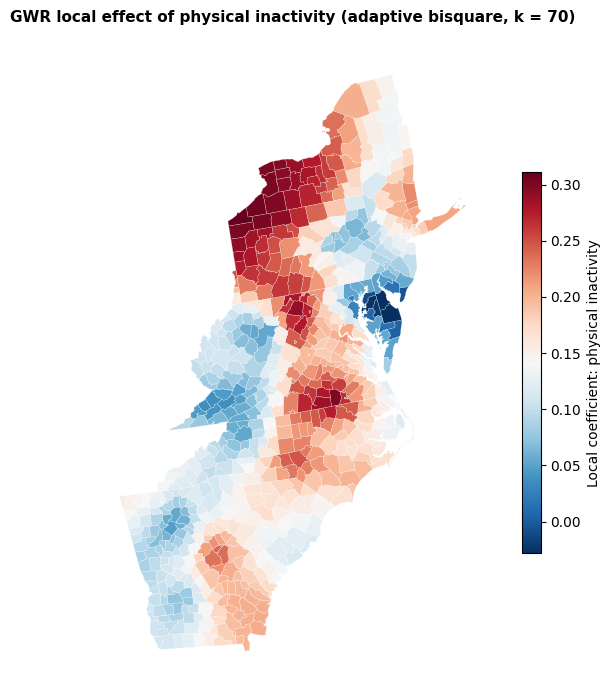

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))
counties.plot(column="gwr_phys", cmap="RdBu_r", legend=True, ax=ax,
              edgecolor="white", linewidth=0.15,
              legend_kwds={"label": "Local coefficient: physical inactivity", "shrink": 0.6})
ax.set_axis_off()
ax.set_title(f"GWR local effect of physical inactivity (adaptive bisquare, k = {best_k})")
plt.tight_layout()
# ALT: Choropleth of the geographically weighted regression coefficient on physical inactivity for Atlantic counties, diverging blue to red around zero, showing the local association with diabetes prevalence is not the same size everywhere.


In [12]:
mgwr = MGWR(
    bw_init=[150_000, 150_000, 150_000, 150_000],
    kernel="bisquare", fixed=True, criterion="AICc",
    tol=1.0, max_iter=4, bw_tol=20_000, n_jobs=1,
)
mgwr.fit(X, y, coords)
bw_km = pd.Series(mgwr.bandwidths_ / 1000, index=["Intercept", *COVARS], name="bandwidth_km")
display(bw_km.round(1).to_frame())
gwr_sd = pd.Series(gwr.coef_.std(axis=0), index=["Intercept", *COVARS], name="gwr_sd")
mgwr_sd = pd.Series(mgwr.coef_.std(axis=0), index=["Intercept", *COVARS], name="mgwr_sd")
display(pd.concat([gwr_sd, mgwr_sd], axis=1).round(3))
if float(bw_km.max() - bw_km.min()) < 1:
    bw_sentence = (
        f"All four bandwidths landed on **{bw_km.max():.0f} km**. "
        f"On this coarse fixed-kernel search the covariates did not separate in scale."
    )
else:
    bw_sentence = (
        f"The widest bandwidth is **{bw_km.idxmax()}** at {bw_km.max():.0f} km and the narrowest is "
        f"**{bw_km.idxmin()}** at {bw_km.min():.0f} km."
    )
display(Markdown(
    f"MGWR AICc on this fixed-kernel fit is **{mgwr.aicc_:.1f}** "
    f"(not on the same scale as the adaptive GWR AICc). {bw_sentence} "
    f"Even so, the local obesity and inactivity coefficients vary less under MGWR "
    f"(SD {mgwr_sd['Obesity']:.3f} and {mgwr_sd['PhysInact']:.3f}) than under the single GWR bandwidth "
    f"(SD {gwr_sd['Obesity']:.3f} and {gwr_sd['PhysInact']:.3f})."
))


,bandwidth_km
Intercept,126.3
Obesity,126.3
PhysInact,126.3
SVI,126.3


,gwr_sd,mgwr_sd
Intercept,1.000,0.719
Obesity,0.062,0.010
PhysInact,0.065,0.008
SVI,0.615,0.663


MGWR AICc on this fixed-kernel fit is **701.2** (not on the same scale as the adaptive GWR AICc). All four bandwidths landed on **126 km**. On this coarse fixed-kernel search the covariates did not separate in scale. Even so, the local obesity and inactivity coefficients vary less under MGWR (SD 0.010 and 0.008) than under the single GWR bandwidth (SD 0.062 and 0.065).

***
## 9. Rates and Uncertainty

`Dia_pct` treats a county of 2,000 people like a county of 2 million. For mapping risk, the count model is the honest one:

$$
O_i \sim \mathrm{Poisson}(E_i \theta_i), \qquad
E_i = n_i \cdot \frac{\sum_j O_j}{\sum_j n_j}, \qquad
\mathrm{SMR}_i = O_i / E_i.
$$

$E_i$ is indirect standardisation with the Atlantic-wide rate as the reference, so the SMRs average about 1. Empirical Bayes (gamma–Poisson, prior fit by maximum likelihood) pulls unstable SMRs toward that mean, harder where $E_i$ is small. The BYM model adds a spatial ICAR term so neighbours share strength as well. The sampler is the built-in Gibbs backend (PyMC is optional). Exceedance $P(\theta_i > 1)$ is the probability map: how sure we are that a county sits above the seaboard rate.


In [13]:
observed = counties["Dia_count"].to_numpy(dtype=float)
population = counties["POP_Total"].to_numpy(dtype=float)
expected = expected_counts(population, observed=observed)
raw_smr = smr(observed, expected)
eb = eb_gamma_poisson(observed, expected, method="mle", alpha=ALPHA)
bym = BYM(
    observed, expected, w, backend="gibbs",
    draws=1000, tune=1000, chains=2, thin=10, seed=SEED, alpha=ALPHA,
)
counties["smr"] = raw_smr
counties["eb"] = eb.estimate
counties["rr"] = bym.rr_mean
counties["p_exceed"] = bym.exceedance(1.0)

rate_summary = pd.DataFrame({
    "SMR": raw_smr, "EB": eb.estimate, "BYM": bym.rr_mean,
}).agg(["mean", "std", "min", "max"]).T
display(rate_summary.round(3))
display(bym.diagnostics.round(3))
shrink = eb.shrinkage
small = expected <= np.quantile(expected, 0.2)
display(Markdown(
    f"The smallest county still has **{observed.min():.0f}** observed cases, so there is little Poisson noise "
    f"left to smooth. SMR standard deviation **{raw_smr.std():.3f}** moves only to **{eb.estimate.std():.3f}** "
    f"after empirical Bayes and **{bym.rr_mean.std():.3f}** after BYM. "
    f"EB prior mean = **{float(eb.prior_mean):.3f}**. "
    f"In the smallest fifth of counties the mean EB weight on the data is "
    f"**{shrink[small].mean():.2f}**, against **{shrink[~small].mean():.2f}** elsewhere "
    f"(1 = no shrinkage). "
    f"BYM max R-hat = **{bym.max_rhat:.3f}**, min ESS = **{bym.min_ess:.0f}**, "
    f"DIC = **{bym.dic:.0f}**, "
    f"mean spatial fraction of the random-effect scale = **{float(np.mean(bym.spatial_fraction)):.2f}**. "
    f"**{(bym.exceedance(1.0) > 0.95).sum()}** of {len(observed)} counties have P(θ > 1) > 0.95: "
    f"with counts this large, a county only slightly above the reference is estimated precisely enough to clear 0.95."
))


,mean,std,min,max
SMR,1.085,0.201,0.425,2.075
EB,1.085,0.199,0.446,2.064
BYM,1.086,0.199,0.466,2.067


,mean,sd,q_lo,q_hi,rhat,ess
parameter,,,,,,
intercept,0.065,0.003,0.059,0.072,1.000,1918.676
tau_u,15.988,2.422,12.145,21.787,1.001,477.217
tau_v,160.858,48.380,96.898,275.979,1.007,334.175


The smallest county still has **142** observed cases, so there is little Poisson noise left to smooth. SMR standard deviation **0.201** moves only to **0.199** after empirical Bayes and **0.199** after BYM. EB prior mean = **1.085**. In the smallest fifth of counties the mean EB weight on the data is **0.96**, against **0.99** elsewhere (1 = no shrinkage). BYM max R-hat = **1.004**, min ESS = **1379**, DIC = **8071**, mean spatial fraction of the random-effect scale = **0.67**. **384** of 666 counties have P(θ > 1) > 0.95: with counts this large, a county only slightly above the reference is estimated precisely enough to clear 0.95.

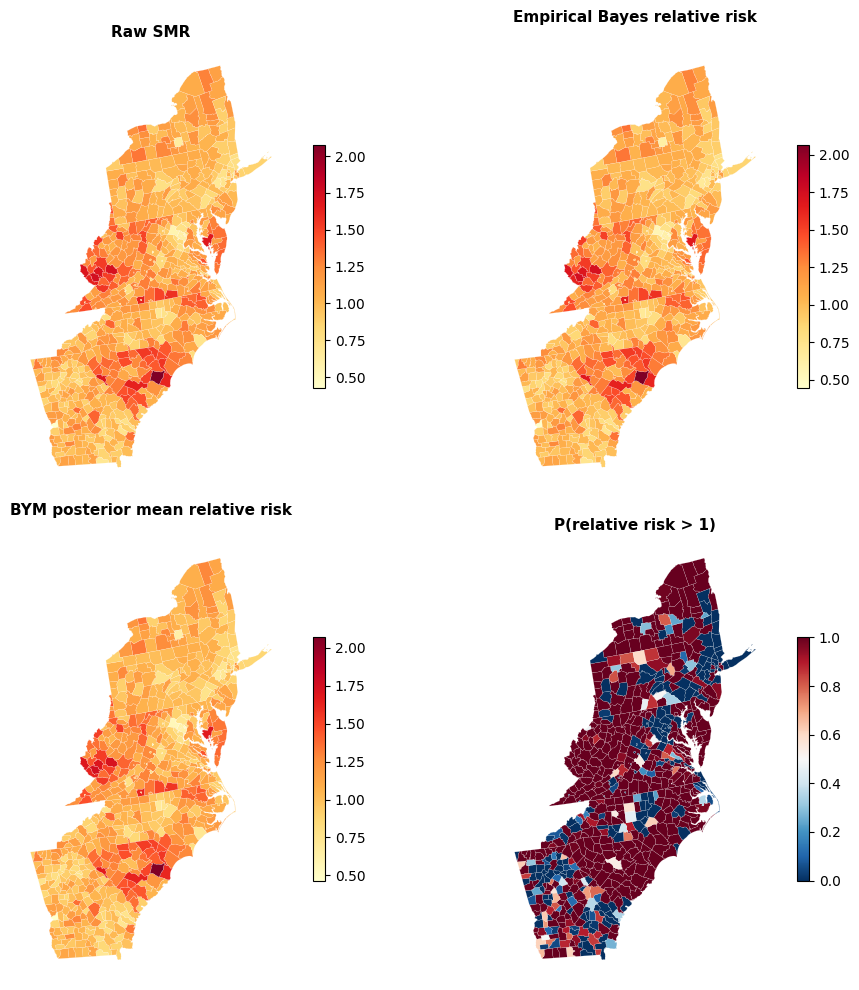

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
panels = [
    ("smr", "Raw SMR", "YlOrRd"),
    ("eb", "Empirical Bayes relative risk", "YlOrRd"),
    ("rr", "BYM posterior mean relative risk", "YlOrRd"),
    ("p_exceed", "P(relative risk > 1)", "RdBu_r"),
]
for ax, (col, title, cmap) in zip(axes.ravel(), panels):
    counties.plot(column=col, cmap=cmap, legend=True, ax=ax,
                  edgecolor="white", linewidth=0.1,
                  legend_kwds={"shrink": 0.55})
    ax.set_axis_off()
    ax.set_title(title)
plt.tight_layout()
# ALT: Four maps of Atlantic county diabetes risk. Raw SMRs are the noisiest, empirical Bayes and BYM posterior means are smoother and closer to 1, and the fourth map shows the posterior probability that relative risk exceeds 1, with high probabilities concentrated in the same inland southern counties as the prevalence hot spots.


***
## 10. Prediction at New Places

The regression sections explain prevalence where we already have a county. Interpolation answers a different question: what prevalence would we assign at a location that is not one of the 666 centroids? Inverse-distance weighting is a local average,

$$
\hat z(s) = \sum_{i \in N_k(s)} d_i^{-p} z_i \;/\; \sum_{i \in N_k(s)} d_i^{-p}.
$$

Leave-one-out error would be flattering, because a held-out county still has neighbours a few kilometres away. Spatial-block cross-validation holds out whole 150 km blocks, which is closer to predicting an unsampled patch. The power and neighbour count are chosen by that score. The winning interpolator is then applied to a grid of locations inside the study area: those cells are not counties, so they are the "new places".


,power,k,rmse,mae,r2
0,1,16,1.436,1.136,0.154
1,2,16,1.441,1.135,0.149
2,1,8,1.454,1.143,0.133
3,2,8,1.468,1.150,0.116
4,4,16,1.513,1.185,0.062
5,4,8,1.537,1.201,0.031


Best spatial-block RMSE is **1.436** percentage points at power **1**, k = **16** (R² = 0.154). The in-sample range of prevalence is 11.10 points, so a block-held-out error of that size is the prediction budget for a place with no nearby county. The grid has **215** cells inside the study area.

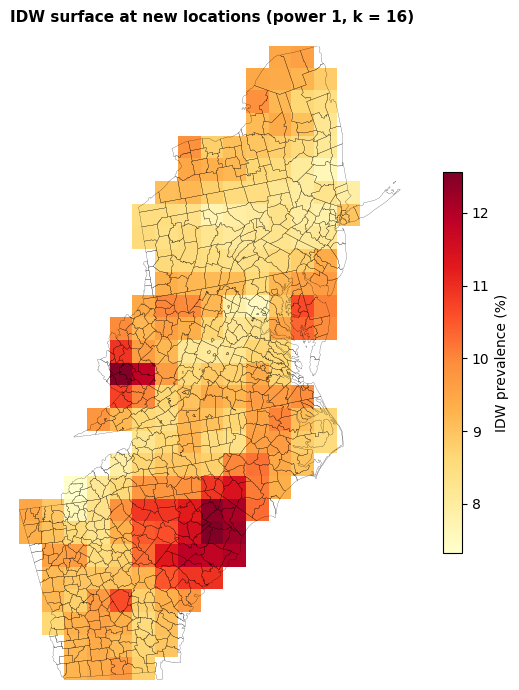

In [15]:
cv_rows = []
for power in (1, 2, 4):
    for k_nn in (8, 16):
        cv = cross_validate(
            IDW(power=power, k=k_nn), coords, y,
            method="spatial_block", k=8, block_size=150_000, seed=SEED,
        )
        cv_rows.append({"power": power, "k": k_nn, "rmse": cv.rmse, "mae": cv.mae, "r2": cv.r2})
cv_table = pd.DataFrame(cv_rows).sort_values("rmse").reset_index(drop=True)
display(cv_table.round(3))
best_power = int(cv_table.loc[0, "power"])
best_idw_k = int(cv_table.loc[0, "k"])
idw = IDW(power=best_power, k=best_idw_k).fit(coords, y)

grid = make_grid(counties, n_cells=28)
grid_pred = idw.predict(grid.coords)
raster = grid.to_raster(grid_pred)
display(Markdown(
    f"Best spatial-block RMSE is **{cv_table.loc[0, 'rmse']:.3f}** percentage points "
    f"at power **{best_power}**, k = **{best_idw_k}** "
    f"(R² = {cv_table.loc[0, 'r2']:.3f}). "
    f"The in-sample range of prevalence is {y.max() - y.min():.2f} points, "
    f"so a block-held-out error of that size is the prediction budget for a place with no nearby county. "
    f"The grid has **{int(np.isfinite(raster).sum())}** cells inside the study area."
))

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(raster, origin="lower", extent=grid.extent, cmap="YlOrRd", aspect="equal")
counties.boundary.plot(ax=ax, color="black", linewidth=0.15)
plt.colorbar(im, ax=ax, shrink=0.6, label="IDW prevalence (%)")
ax.set_axis_off()
ax.set_title(f"IDW surface at new locations (power {best_power}, k = {best_idw_k})")
plt.tight_layout()
# ALT: Smooth inverse-distance-weighted surface of predicted diabetes prevalence over the Atlantic study area, drawn under thin county boundaries, yellow where prevalence is lower and red where it is higher, filling locations between the county centroids.


***
## 11. Decision Log and Summary Figure

The log is the analysis. Someone re-running the notebook should not have to recover the weights, the correction, or the seed from a methods paragraph written later.


,choice,setting,reason
0,CRS,EPSG:5070,Declared Conus Albers; audit passed; metres
1,Coordinates,polygon centroids,Not stored x/y; not representative points
2,Weights,"Queen, row-standardised",Connected; 0 islands; KNN I stayed in a narrow...
3,Island rule,link to nearest non-island,Applied to the 50 km band (3 islands); Queen n...
4,Alpha,0.05,"Same threshold for Gi*, LISA, and local GWR p-..."
5,Multiple testing,FDR for Gi*; LISA shown both ways,Permutation LISA p-values bottom out at 2/1000...
6,Permutations,999,Global Moran and LISA
7,Seed,7,"Moran, LISA, BYM, spatial-block folds"
8,Mean model,SEM,"Lowest AIC among OLS, SLM, SEM after the LM tests"
9,GWR,"adaptive bisquare, k = 70","Lowest AICc on the grid 40, 70, 110, 160"


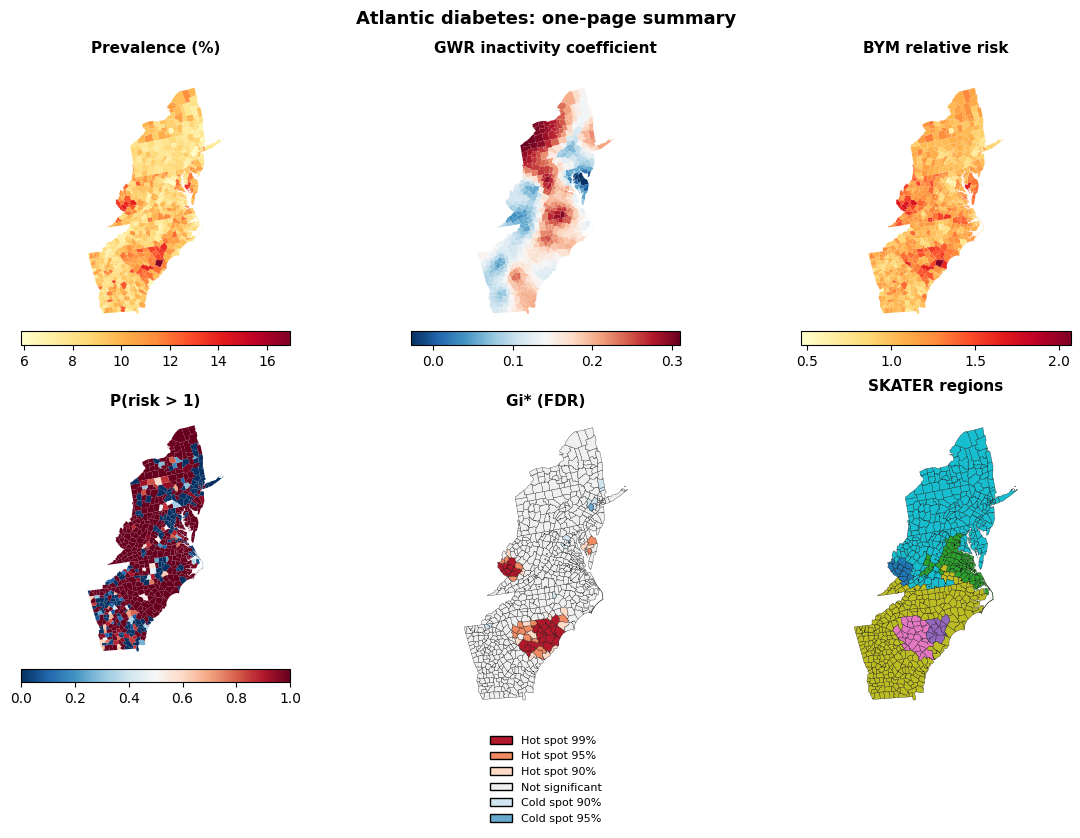

In [16]:
decisions = pd.DataFrame([
    {"choice": "CRS", "setting": "EPSG:5070", "reason": "Declared Conus Albers; audit passed; metres"},
    {"choice": "Coordinates", "setting": "polygon centroids", "reason": "Not stored x/y; not representative points"},
    {"choice": "Weights", "setting": "Queen, row-standardised", "reason": "Connected; 0 islands; KNN I stayed in a narrow band"},
    {"choice": "Island rule", "setting": "link to nearest non-island", "reason": f"Applied to the 50 km band ({len(band.islands())} islands); Queen needed none"},
    {"choice": "Alpha", "setting": str(ALPHA), "reason": "Same threshold for Gi*, LISA, and local GWR p-values"},
    {"choice": "Multiple testing", "setting": "FDR for Gi*; LISA shown both ways", "reason": "Permutation LISA p-values bottom out at 2/1000, which caps how many FDR rejections BH can return"},
    {"choice": "Permutations", "setting": str(PERM), "reason": "Global Moran and LISA"},
    {"choice": "Seed", "setting": str(SEED), "reason": "Moran, LISA, BYM, spatial-block folds"},
    {"choice": "Mean model", "setting": best_name, "reason": "Lowest AIC among OLS, SLM, SEM after the LM tests"},
    {"choice": "GWR", "setting": f"adaptive bisquare, k = {best_k}", "reason": "Lowest AICc on the grid 40, 70, 110, 160"},
    {"choice": "MGWR", "setting": "fixed bisquare, 20 km tolerance, ≤ 4 iterations", "reason": "Adaptive grid search is too expensive at n = 666"},
    {"choice": "Rates", "setting": "SMR → EB (MLE) → BYM Gibbs", "reason": "1000 draws, 1000 tune, 2 chains, thin 10"},
    {"choice": "Prediction", "setting": f"IDW power {best_power}, k = {best_idw_k}", "reason": "Lowest 150 km spatial-block RMSE"},
    {"choice": "Space–time", "setting": "not fit", "reason": "spatialstats.spacetime is a stub; this file is a cross-section"},
])
display(decisions)

fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))
specs = [
    ("Dia_pct", "Prevalence (%)", "YlOrRd", False),
    ("gwr_phys", "GWR inactivity coefficient", "RdBu_r", False),
    ("rr", "BYM relative risk", "YlOrRd", False),
    ("p_exceed", "P(risk > 1)", "RdBu_r", False),
]
for ax, (col, title, cmap, _) in zip(list(axes.ravel())[:4], specs):
    counties.plot(column=col, cmap=cmap, ax=ax, edgecolor="none", legend=True,
                  legend_kwds={"shrink": 0.55, "orientation": "horizontal", "pad": 0.02})
    ax.set_axis_off()
    ax.set_title(title)
gi.plot(counties, ax=axes[1, 1])
axes[1, 1].set_title("Gi* (FDR)")
leg = axes[1, 1].get_legend()
if leg is not None:
    leg.set_loc("upper center")
    leg.set_bbox_to_anchor((0.5, -0.04))
regions.plot(counties, ax=axes[1, 2], cmap="tab10", legend=False)
axes[1, 2].set_title("SKATER regions")
fig.suptitle("Atlantic diabetes: one-page summary", fontsize=13, fontweight="bold")
plt.tight_layout()
# ALT: Six-panel summary of the Atlantic diabetes study: prevalence, the local GWR inactivity coefficient, BYM relative risk, the probability that risk exceeds 1, Gi-star hot and cold spots, and six SKATER regions.


***
## 12. Summary and Conclusions


In [17]:
display(Markdown(f'''
Prevalence in the 666 Atlantic counties is spatially structured. Under Queen weights, Moran's I is **{moran.I:.3f}** (permutation p = **{moran.p_value:.3f}**). Gi\* after FDR marks **{int(hot.sum())}** hot-spot counties and **{int(cold.sum())}** cold-spot counties. Uncorrected LISA puts **{int(hh.sum())}** counties in high-high clusters; the Jaccard overlap with Gi\* hot spots is **{jaccard(hot, hh):.2f}**. FDR LISA keeps **{int((lisa_fdr.labels != 'Not significant').sum())}** counties, about as many as the permutation floor allows Benjamini–Hochberg to declare, not a blank map and not the full uncorrected cluster set.

Obesity, inactivity, and social vulnerability do not leave spatially independent residuals. The LM tests point to **{lm.recommendation()}**, and **{best_name}** has the lowest AIC (**{cmp.loc[best_name, 'aic']:.1f}**). That global coefficient is an average: the GWR inactivity slope at k = {best_k} runs from **{local_phys.min():.3f}** to **{local_phys.max():.3f}**. The fixed-kernel MGWR search did not give the covariates different bandwidths; it did shrink the local obesity and inactivity slopes relative to that single GWR bandwidth.

Mapped as a rate, smoothing barely changes the picture, because the smallest county still has **{observed.min():.0f}** cases. Empirical Bayes and BYM move the standard deviation only from **{raw_smr.std():.3f}** to **{eb.estimate.std():.3f}** and **{bym.rr_mean.std():.3f}**. **{(counties['p_exceed'] > 0.95).sum()}** counties have a posterior probability above 0.95 of exceeding the seaboard rate, which here means the estimates are precise, not that the prior invented hot spots.

Predicting a place that is not a sampled county is harder than fitting a county we already observed. The best IDW setting on 150 km blocks has RMSE **{cv_table.loc[0, 'rmse']:.2f}** percentage points. That is the number to quote for a new location, not the in-sample GWR residual.

Nothing here is a space–time result. The file is one cross-section, and `spatialstats.spacetime` does not yet implement the cube.
'''))



Prevalence in the 666 Atlantic counties is spatially structured. Under Queen weights, Moran's I is **0.371** (permutation p = **0.001**). Gi\* after FDR marks **58** hot-spot counties and **12** cold-spot counties. Uncorrected LISA puts **61** counties in high-high clusters; the Jaccard overlap with Gi\* hot spots is **0.83**. FDR LISA keeps **27** counties, about as many as the permutation floor allows Benjamini–Hochberg to declare, not a blank map and not the full uncorrected cluster set.

Obesity, inactivity, and social vulnerability do not leave spatially independent residuals. The LM tests point to **Spatial error model (both robust tests significant; larger statistic chosen — consider SARMA/Durbin)**, and **SEM** has the lowest AIC (**1559.4**). That global coefficient is an average: the GWR inactivity slope at k = 70 runs from **-0.028** to **0.311**. The fixed-kernel MGWR search did not give the covariates different bandwidths; it did shrink the local obesity and inactivity slopes relative to that single GWR bandwidth.

Mapped as a rate, smoothing barely changes the picture, because the smallest county still has **142** cases. Empirical Bayes and BYM move the standard deviation only from **0.201** to **0.199** and **0.199**. **384** counties have a posterior probability above 0.95 of exceeding the seaboard rate, which here means the estimates are precise, not that the prior invented hot spots.

Predicting a place that is not a sampled county is harder than fitting a county we already observed. The best IDW setting on 150 km blocks has RMSE **1.44** percentage points. That is the number to quote for a new location, not the in-sample GWR residual.

Nothing here is a space–time result. The file is one cross-section, and `spatialstats.spacetime` does not yet implement the cube.


***
## 13. Resources

### Textbooks and papers

| Reference | Notes |
|---|---|
| Anselin, L. (1988). *Spatial Econometrics*. Kluwer. | Spatial lag and spatial error models in Section 7 |
| Anselin, L. (1995). Local indicators of spatial association — LISA. *Geographical Analysis*. | Local Moran clusters in Section 6 |
| Anselin, L., Bera, A. K., Florax, R. & Yoon, M. J. (1996). Simple diagnostic tests for spatial dependence. *Regional Science and Urban Economics*. | The LM decision rule in Section 7 |
| Getis, A. & Ord, J. K. (1992). The analysis of spatial association by use of distance statistics. *Geographical Analysis*. | Gi\* |
| Assunção, R. M. et al. (2006). Efficient regionalization techniques for socio-economic geographical units using minimum spanning trees. *International Journal of Geographical Information Science*. | SKATER |
| Brunsdon, C., Fotheringham, A. S. & Charlton, M. E. (1996). Geographically weighted regression. *Geographical Analysis*. | Section 8 |
| Fotheringham, A. S., Yang, W. & Kang, W. (2017). Multiscale geographically weighted regression. *Annals of the American Association of Geographers*. | MGWR bandwidths |
| Marshall, R. J. (1991). Mapping disease and mortality rates using empirical Bayes estimators. *International Journal of Epidemiology*. | Section 9 |
| Besag, J., York, J. & Mollié, A. (1991). Bayesian image restoration, with two applications in spatial statistics. *Annals of the Institute of Statistical Mathematics*. | BYM |

### In this library

| Object | Role |
|---|---|
| `core.to_crs`, `SpatialData` | Section 3 audit and reprojection |
| `weights.Queen`, `KNN`, `DistanceBand`, `W` | Section 4 |
| `esda.Moran`, `viz.moran_scatter` | Section 5 |
| `cluster.getis_ord_gi`, `local_moran_clusters`, `skater`, `jaccard` | Section 6 |
| `regression.OLS`, `SpatialLag`, `SpatialError`, `compare_models` | Section 7 |
| `gwmodel.GWR`, `MGWR` | Section 8 |
| `bayes.expected_counts`, `smr`, `eb_gamma_poisson`, `BYM` | Section 9 |
| `interpolate.IDW`, `cross_validate`, `make_grid` | Section 10 |
